## FX Short Run Notebook
Notebook flow: configure run, fetch data, validate health, run gate logic, visualize, sweep, and save artifacts.

### Run Setup

In [1]:
import os
import sys
import json
import pathlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import importlib
import fxshort_gates
import config
import functions2
import functions1

importlib.reload(fxshort_gates)
importlib.reload(functions2)
importlib.reload(functions1)

# Runtime config
RUN_MODE = "research"  # "research" or "production"
ticker = "GBPCHF"
window_start = "2022-08-04"
window_end = None

runtime_params, run_meta = functions1.build_runtime_config(
    dict(config.params),
    run_mode=RUN_MODE,
    ticker=ticker,
    window_start=window_start,
    window_end=window_end,
)
MAX_AGE = runtime_params["max_age"]
FORCE_REFRESH = bool(run_meta["force_refresh"])

print('runtime_params:', runtime_params)
print("run_id:", run_meta["run_id"])
print("mode:", run_meta["run_mode"])
print("datasource:", runtime_params["datasource"])
print("max_age:", runtime_params["max_age"], "force_refresh:", FORCE_REFRESH)

runtime_params: {'start': '2022-08-04', 'end': '20260311', 'datasource': 'stooq', 'max_age': 22.0}
run_id: 527b973d6504
mode: research
datasource: stooq
max_age: 22.0 force_refresh: False


### Fetch And Prepare Series

In [2]:
df = functions1.fetch_csv_robust(
    ticker=ticker,
    params=runtime_params,
    force_refresh=FORCE_REFRESH,
 )
s = functions1.sort_cols(df)
s = functions2.standardize_fx_daily_index(s)
s = functions2.trim_series(s, window_start, window_end)

print(ticker)
print('series starts:', s.index[0].date())
print('series ends:', s.index[-1].date())
print("rows:", len(s))

GBPCHF - using cached data
gap days: -2404
required start: 2022-08-04 
data start: 2016-01-04
sort_cols: ohlc not set. True only needed for ATR calculations for vol stops. Defaulting to False
GBPCHF
series starts: 2022-08-04
series ends: 2026-03-10
rows: 930


### Cache Health

In [3]:
cache_status = functions1.print_cache_status(ticker)

CACHE STATUS [WARN] GBPCHF
cache meta path: /Users/alexwebb/laptop_coding/risk_matrix/cache/GBPCHF.meta.json
last_update_mode: incremental_noop
last_update_utc: 2026-03-11T14:03:30Z
last_full_refresh_utc: 2026-03-11T14:02:49Z


### Smoke Checks

In [4]:
# Lightweight deterministic smoke checks
assert runtime_params["max_age"] == MAX_AGE
assert isinstance(s, pd.Series) and len(s) > 50

toy = pd.Series(
    [100.0, 99.5, 99.0, 98.8, 98.6, 98.7, 98.9, 98.4, 98.1, 97.9],
    index=pd.date_range("2024-01-01", periods=10, freq="B"),
    dtype=float,
)
toy_gate = fxshort_gates.fxshort_gate(
    toy,
    slope_window=3,
    consec=1,
    shift_for_signal=True,
    require_carry=False,
    min_run_days=1,
    slope_source="log_price",
)
assert toy_gate.index.equals(toy.index)
assert toy_gate.dtype == bool
print("smoke checks passed")

smoke checks passed


### Run gate with Frozen params

In [47]:

carry_ann = 0.04


print(ticker)
gate_stateon = fxshort_gates.fxshort_gate(
    # 2025-4-10
    s,
    carry_ann=carry_ann,
    buffer20=0.00,
    slope_window=15,
    consec=2,
    slope_entry_threshold=-1e-4,
    slope_exit_threshold=0.000,
    grace_days=2,
    require_carry=False,
    shift_for_signal=True,
    consec_rises_kill=3, 
    min_run_days=3,
    slope_source="log_price"
    
)

# --- Example usage after you compute gate_stateon ---
trades, stats = fxshort_gates.analyze_gate_trades(s, gate_stateon, position="short")
# print(trades.head(1))
print(stats)
# After you get trades from analyze_gate_trades
FEE_PER_TRADE = 0.00004  # 5bp round-trip, adjust as needed
trades["carry_cost"] = trades["holding_days"] * (carry_ann / 365)
trades["fee_cost"] = FEE_PER_TRADE
trades["net_pct_return"] = trades["pct_return"] - trades["carry_cost"] - trades["fee_cost"]

# Recompute summary stats on net_pct_return..... 0.00128
net_expectancy = trades["net_pct_return"].mean()
print(f"Net expectancy per trade after carry and fees: {net_expectancy:.5f}")
print('GATE ON NOW?', gate_stateon.iloc[-1])

GBPCHF
{'trades': 44, 'win_rate': 0.4090909090909091, 'total_pct_return': np.float64(0.0029940031672010675), 'avg_pct_return': np.float64(6.804552652729699e-05), 'avg_win': np.float64(0.011865923613641357), 'avg_loss': np.float64(-0.008099716226090129), 'expectancy_per_trade': np.float64(6.804552652729754e-05), 'median_holding_days': 7.0, 'avg_MFE_pct': np.float64(0.010223472039610071), 'avg_MAE_pct': np.float64(0.0063560099982747364), 'max_draw_trade_pct': -0.017285324526134457, 'best_trade_pct': 0.03824788747133153}
Net expectancy per trade after carry and fees: -0.00149
GATE ON NOW? True


### Plot Gate Overlay

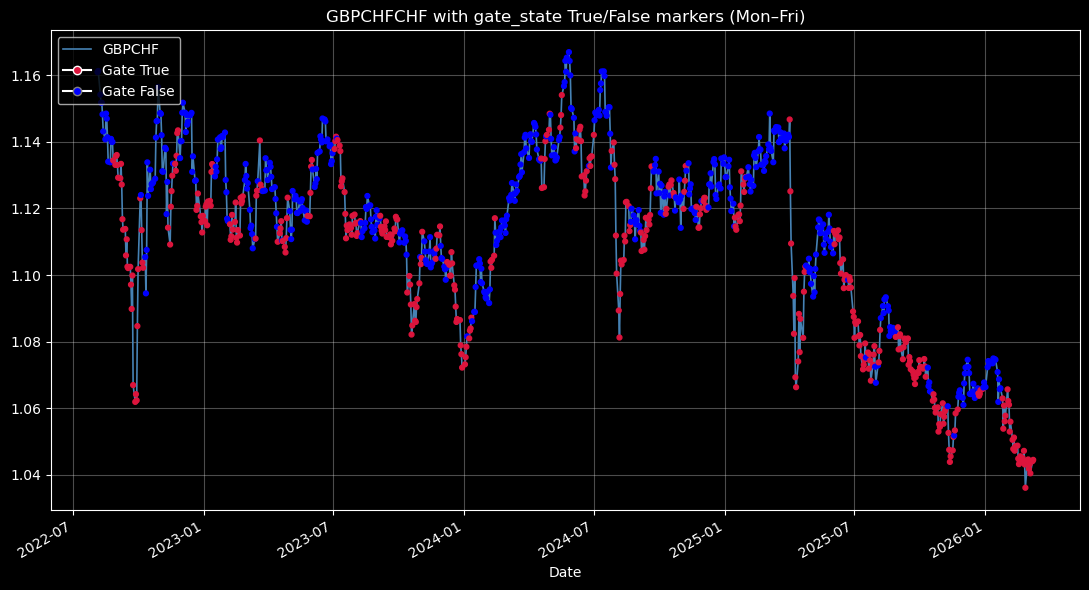

In [50]:

plt.style.use('dark_background')

TAIL_BARS = None
# Use Mon–Fri only for plotting to avoid weekend prints often present in FX feeds
# s=s.tail(200)
s_std_plot = functions2.standardize_fx_daily_index(s)

# Select tail for plotting
s_plot = s_std_plot.tail(TAIL_BARS) if TAIL_BARS else s_std_plot
fig, ax = plt.subplots(figsize=(11, 6))
# Base price plot
s_plot.plot(ax=ax, color='steelblue', lw=1.2, label=ticker)
# Align gate_state to price index (gate is Mon–Fri too)
g = gate_stateon.reindex(s_plot.index).fillna(False).astype(bool)
# print(f'gateon aligned to price (last 20 rows):\n{gate_stateon}')
# Overlay markers colored by gate_state state on the price series
colors = np.where(g.values, 'crimson', 'blue')
ax.scatter(s_plot.index, s_plot.values, c=colors, s=12, zorder=3)
# Legend: include price and gate_state state keys
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
gate_true = Line2D([0],[0], marker='o', color='w', label='Gate True', markerfacecolor='crimson', markersize=6)
gate_false = Line2D([0],[0], marker='o', color='w', label='Gate False', markerfacecolor='blue', markeredgecolor='gray', markersize=6)
ax.legend(handles + [gate_true, gate_false], labels + ['Gate True','Gate False'], loc='upper left')
ax.set_title(f'{ticker}CHF with gate_state True/False markers (Mon–Fri)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 ### Run sweep once a week/month

In [ ]:
import importlib
import scripts.sample_window_sweep as sws

# Ensure latest local module code is loaded in this kernel.
importlib.reload(fxshort_gates)

# Robustness mode: rolling monthly anchors + expanding windows per anchor.
USE_ROLLING_EXPANDING_WINDOWS = True
MIN_WINDOW_MONTHS = 12
ROLL_START_STEP_MONTHS = 3
MAX_WINDOWS = None  # Set int to limit runtime, e.g. 12

# Leaner sweep grid to reduce overfit risk and runtime.
SWEEP_SLOPE_WINDOWS = (6, 10, 15, 20)
SWEEP_CONSEC = (1, 2)
SWEEP_ENTRY_THR = (0.0, -1e-4)
SWEEP_EXIT_OFFSETS = (0.0, 1e-4)
SWEEP_RISES_KILL = (0, 2)
SWEEP_REQUIRE_CARRY = (False, True)
SWEEP_GRACE_DAYS = (2,)

# Scale min_trades with window length for fair filtering across short/long windows.
TARGET_TRADES_PER_YEAR = 18
MIN_TRADES_FLOOR = 10
MIN_TRADES_CAP = 50

start, end = functions2.get_window_dates(s)

if USE_ROLLING_EXPANDING_WINDOWS:
    windows = sws.rolling_expanding_month_windows(
        s.index,
        min_months=MIN_WINDOW_MONTHS,
        roll_start_step_months=ROLL_START_STEP_MONTHS,
    )
    if MAX_WINDOWS is not None:
        windows = windows[-MAX_WINDOWS:]
else:
    windows = [(start, end, None, 0)]

if not windows:
    raise ValueError("No windows generated for sweep.")

frames = []
trial_attempted = 0
trial_failed = 0
short_window_skipped = 0

for w_start, w_end, w_months, roll_seq in windows:
    s_win = s.loc[w_start:w_end]
    if len(s_win) < 60:
        short_window_skipped += 1
        continue

    months = int(w_months) if w_months is not None else max(1, int(round(len(s_win) / 21)))
    min_trades_win = int(round(TARGET_TRADES_PER_YEAR * months / 12.0))
    min_trades_win = max(MIN_TRADES_FLOOR, min(MIN_TRADES_CAP, min_trades_win))

    trial_attempted += 1
    df_win = fxshort_gates.sweep_fxshort_gate(
        ticker,
        price=s_win,
        gate_fn=fxshort_gates.fxshort_gate,
        slope_window_vals=SWEEP_SLOPE_WINDOWS,
        consec_vals=SWEEP_CONSEC,
        slope_entry_thr_vals=SWEEP_ENTRY_THR,
        slope_exit_thr_offsets=SWEEP_EXIT_OFFSETS,
        consec_rises_kill_vals=SWEEP_RISES_KILL,
        require_carry_vals=SWEEP_REQUIRE_CARRY,
        buffer20_vals=(0.002,),
        max_combos=None,
        min_trades=min_trades_win,
        grace_days_vals=SWEEP_GRACE_DAYS,
        plot_top_gate=False,
    )

    if df_win is None or len(df_win) == 0:
        trial_failed += 1
        continue

    df_win = df_win.copy()
    df_win["window_start"] = str(pd.Timestamp(w_start).date())
    df_win["window_end"] = str(pd.Timestamp(w_end).date())
    df_win["window_months"] = months
    df_win["roll_seq"] = int(roll_seq)
    df_win["min_trades_window"] = int(min_trades_win)
    frames.append(df_win)

if not frames:
    raise ValueError("Sweep returned no rows across generated windows; check parameters/window.")

results = pd.concat(frames, ignore_index=True)
results["run_id"] = run_meta["run_id"]
results["run_mode"] = run_meta["run_mode"]
results["created_utc"] = run_meta["created_utc"]
results["window_mode"] = "rolling_expanding" if USE_ROLLING_EXPANDING_WINDOWS else "single"

rank_col = "net_expectancy_per_trade" if "net_expectancy_per_trade" in results.columns else "total_pct_return"
results = results.sort_values(rank_col, ascending=False, kind="mergesort").reset_index(drop=True)

failed_pct = (100.0 * trial_failed / trial_attempted) if trial_attempted else 0.0

top = fxshort_gates.summarize_top(results, top=5)
print(ticker)
print(start.date(), end.date())
print("window_mode:", results["window_mode"].iloc[0])
print("windows attempted:", trial_attempted)
print("windows failed (no valid config):", trial_failed, f"({failed_pct:.1f}%)")
print("windows skipped (too short):", short_window_skipped)
print("windows with results:", len(results[["window_start", "window_end"]].drop_duplicates()))
print(
    "min_trades_window range:",
    int(results["min_trades_window"].min()),
    "->",
    int(results["min_trades_window"].max()),
)
print(top.to_string(index=False))
print("rows in sweep:", len(results))

No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid gate configurations found in sweep.
No valid g

### Plot Best Sweep Result

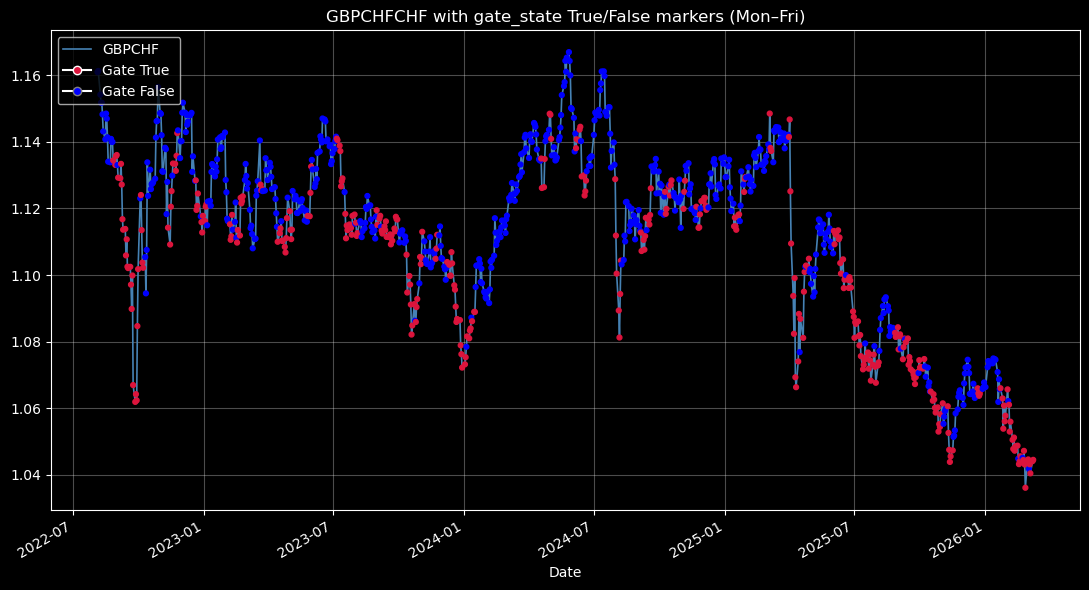

Plotted best sweep config: {'slope_window': 15, 'consec': 2, 'slope_entry_threshold': 0.0, 'slope_exit_threshold': 0.0, 'require_carry': False, 'consec_rises_kill': 2, 'carry_ann': 0.04, 'buffer20': 0.002, 'grace_days': 2, 'min_run_days': 3, 'slope_source': 'log_price'}


In [6]:
# One plot only: use the top-ranked configuration after all windows are evaluated.
best_row = results.iloc[0]

best_cfg = {
    "slope_window": int(best_row["slope_window"]),
    "consec": int(best_row["consec"]),
    "slope_entry_threshold": float(best_row["slope_entry_thr"]),
    "slope_exit_threshold": float(best_row["slope_exit_thr"]),
    "require_carry": bool(best_row["require_carry"]),
    "consec_rises_kill": int(best_row["consec_rises_kill"]),
    "carry_ann": float(best_row.get("carry_ann", 0.04)),
    "buffer20": float(best_row.get("buffer20", 0.002)),
    "grace_days": int(best_row.get("grace_days", 2)),
    "min_run_days": 3,
    "slope_source": str(best_row.get("slope_source", "log_price")),
}

best_gate = fxshort_gates.fxshort_gate(
    s,
    shift_for_signal=True,
    **best_cfg,
 )

fxshort_gates.plot_gate_state(ticker, s, best_gate)
print("Plotted best sweep config:", best_cfg)

### save results

In [53]:
save_dir = pathlib.Path(".")
print("saving to directory:", save_dir.resolve())
save_dir.mkdir(parents=True, exist_ok=True)

results_to_save = results.copy()
float_cols = results_to_save.select_dtypes(include=["float64", "float32"]).columns
results_to_save[float_cols] = results_to_save[float_cols].round(6)

# Atomic write to run-specific file + metadata sidecar for reproducibility.
run_csv = save_dir / f"sweep_results_{run_meta['run_id']}.csv"
tmp_csv = run_csv.with_suffix(".tmp")
results_to_save.to_csv(tmp_csv, index=False)
os.replace(tmp_csv, run_csv)

meta_path = save_dir / f"sweep_results_{run_meta['run_id']}.meta.json"
tmp_meta = meta_path.with_suffix(".tmp")
with open(tmp_meta, "w", encoding="utf-8") as f:
    json.dump(run_meta, f, indent=2, sort_keys=True)
os.replace(tmp_meta, meta_path)

print("saved:", run_csv)
print("metadata:", meta_path)

saving to directory: /Users/alexwebb/laptop_coding/risk_matrix/fx_hedges
saved: sweep_results_0462c5433be3.csv
metadata: sweep_results_0462c5433be3.meta.json
